# Prediksi Risiko Kredit Nasabah menggunakan XGBoost dan Random Forest
### Studi Kasus: South German Credit Dataset (UCI Machine Learning Repository)

**Mata Kuliah:** Predictive Analytics — Midterm Project (UTS)
**Nama:** Suci Fransisca Sisilia Rahmat (Sisil)
**NIM:** 24120500008
**Program Studi:** Data Science, Universitas Cakrawala
**Jenis Proyek:** Classification (Klasifikasi Biner)
**Tanggal Pengerjaan:** 27 September 2026

---


## 1. Project Overview

**Konteks Masalah.**
Bank dan lembaga pembiayaan menghadapi trade-off klasik setiap kali menyetujui aplikasi kredit: menolak nasabah yang sebenarnya layak akan menghilangkan pendapatan bunga (*opportunity cost*), sedangkan menyetujui nasabah yang berisiko gagal bayar akan menimbulkan kerugian langsung (*credit loss*). Di lapangan, keputusan ini biasanya masih banyak mengandalkan *scorecard* manual dan judgment credit analyst, yang lambat untuk volume aplikasi besar dan rawan bias individu. Model prediktif yang terlatih dari data historis pengajuan kredit dapat mempercepat proses screening awal sekaligus membuat kriteria keputusan lebih konsisten dan bisa diaudit.

**Tujuan Prediksi.**
Proyek ini membangun model klasifikasi biner untuk memprediksi `credit_risk` seorang pemohon kredit, yaitu apakah pemohon tergolong **good risk (1)** atau **bad risk (0)**, berdasarkan 20 atribut yang direkam saat pengajuan (riwayat rekening, riwayat kredit, tujuan pinjaman, jumlah pinjaman, tabungan, lama bekerja, status personal, properti, usia, pekerjaan, dan lain-lain).

**Siapa yang memakai hasil ini.**
Stakeholder utama adalah *credit risk analyst* dan *loan officer* di lembaga pembiayaan konsumen. Model ini dimaksudkan sebagai **decision-support tool** pada tahap *pre-screening* — bukan pengganti keputusan akhir analis, mengingat keterbatasan data (dijelaskan di bagian limitations).

**Unit Analisis dan Kapan Data Diambil.**
Satu baris data merepresentasikan satu aplikasi kredit individual yang diajukan ke sebuah bank di Jerman Selatan. Dataset ini adalah versi terkoreksi (2019) dari German Credit Data klasik (Statlog), dipublikasikan oleh UCI Machine Learning Repository.

**Jenis Task, Target, dan Value Bisnis.**
- Jenis task: *classification* (biner)
- Target: `credit_risk` (0 = bad/berisiko gagal bayar, 1 = good/layak kredit)
- Value bisnis: mengurangi kerugian akibat kredit macet (false negative — model bilang "good" padahal "bad") sambil tetap menjaga jumlah aplikasi baik yang ditolak secara tidak perlu (false positive) tidak terlalu tinggi.


## 2. Dataset Description and Source

**Sumber data:**
- **Judul dataset:** South German Credit (UPDATE)
- **Pemilik/Publisher:** UCI Machine Learning Repository (kontributor: Dr. Hans Hofmann; versi update oleh Dr. Ulrike Grömping, Beuth University of Applied Sciences Berlin)
- **Link akses:** https://archive.ics.uci.edu/dataset/573/south+german+credit+update
- **Tanggal akses:** 27 September 2026
- **Lisensi/format asli:** file `.asc` (whitespace-separated) beserta `codetable.txt` yang mendefinisikan makna tiap kode kategori.

Dataset ini sengaja dipilih ketimbang versi "German Credit" klasik yang lebih populer karena versi *update* (2019) sudah memperbaiki beberapa kesalahan pengkodean atribut pada versi lama — sehingga lebih valid untuk dipakai sebagai dasar keputusan, bukan sekadar dataset latihan.

**Dimensi data:** 1.000 observasi (baris) × 20 variabel prediktor + 1 variabel target.

**Unit observasi:** satu aplikasi kredit individu.

**Data dictionary ringkas** (nama variabel asli dalam bahasa Jerman sengaja diterjemahkan ke bahasa Inggris sesuai `codetable.txt` resmi agar konsisten dengan literatur):


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support, f1_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 30)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [11]:
import zipfile
import os

# Define the correct UCI URL for the South German Credit Dataset zip file.
# The previously extracted zip file 'credit+approval (1).zip' was the wrong dataset.
download_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00573/SouthGermanCredit.zip"
zip_filename = "SouthGermanCredit.zip"
zip_path = os.path.join('/content/', zip_filename)

# Download the correct zip file using wget
print(f"Downloading '{zip_filename}' from UCI...")
# Use !wget for shell command execution in Colab
!wget -q -O {zip_path} {download_url}

# Check if download was successful
if os.path.exists(zip_path):
    print(f"'{zip_filename}' downloaded successfully.")
    # Extract the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"'{zip_filename}' extracted successfully. You should now find 'SouthGermanCredit.asc'.")
else:
    print(f"Failed to download '{zip_filename}'. Please check the URL or your internet connection.")

'SouthGermanCredit.zip' downloaded successfully.
'SouthGermanCredit.zip' extracted successfully. You should now find 'SouthGermanCredit.asc'.


In [13]:
# Konversi data mentah (.asc) dari UCI menjadi CSV

RAW_ASC_PATH = "SouthGermanCredit.asc"
CSV_PATH = "south_german_credit.csv"

column_names = ['status','duration','credit_history','purpose','amount','savings',
                'employment_duration','installment_rate','personal_status_sex','other_debtors',
                'present_residence','property','age','other_installment_plans','housing',
                'number_credits','job','people_liable','telephone','foreign_worker','credit_risk']

if os.path.exists(RAW_ASC_PATH):
    df_raw = pd.read_csv(RAW_ASC_PATH, sep=r'\s+', header=0, names=column_names, encoding='latin-1')
    df_raw.to_csv(CSV_PATH, index=False)
    print(f"Berhasil konversi '{RAW_ASC_PATH}' -> '{CSV_PATH}'  |  shape: {df_raw.shape}")
else:
    print(f"'{RAW_ASC_PATH}' tidak ditemukan di direktori kerja — melanjutkan langsung dengan '{CSV_PATH}' yang sudah tersedia.")

Berhasil konversi 'SouthGermanCredit.asc' -> 'south_german_credit.csv'  |  shape: (1000, 21)


In [14]:
DATA_PATH = "south_german_credit.csv"
df = pd.read_csv(DATA_PATH)
print("Ukuran data:", df.shape)
df.head()


Ukuran data: (1000, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


**Data dictionary lengkap** (kode -> makna, sesuai `codetable.txt` resmi UCI):

| Variabel | Tipe | Keterangan |
|---|---|---|
| `status` | ordinal (1-4) | status rekening giro saat ini |
| `duration` | numerik | jangka waktu kredit (bulan) |
| `credit_history` | ordinal (0-4) | riwayat pembayaran kredit sebelumnya |
| `purpose` | nominal (0-10) | tujuan pinjaman (mobil, elektronik, pendidikan, dll.) |
| `amount` | numerik | jumlah pinjaman (DM) |
| `savings` | ordinal (1-5) | saldo tabungan |
| `employment_duration` | ordinal (1-5) | lama bekerja di pekerjaan saat ini |
| `installment_rate` | ordinal (1-4) | cicilan sebagai % dari pendapatan (semakin besar kode = % semakin kecil) |
| `personal_status_sex` | nominal (1-4) | status personal & jenis kelamin |
| `other_debtors` | nominal (1-3) | ada tidaknya penjamin/co-applicant |
| `present_residence` | ordinal (1-4) | lama tinggal di alamat saat ini |
| `property` | ordinal (1-4) | jenis aset yang dimiliki |
| `age` | numerik | usia pemohon (tahun) |
| `other_installment_plans` | nominal (1-3) | cicilan lain di bank/toko lain |
| `housing` | nominal (1-3) | status tempat tinggal (sewa/milik sendiri/gratis) |
| `number_credits` | ordinal (1-4) | jumlah kredit yang sudah dimiliki di bank ini |
| `job` | ordinal (1-4) | tingkat kualifikasi pekerjaan |
| `people_liable` | ordinal (1-2) | jumlah tanggungan |
| `telephone` | nominal (1-2) | punya telepon atas nama sendiri |
| `foreign_worker` | nominal (1-2) | status pekerja asing |
| **`credit_risk`** | **target biner** | **0 = bad (gagal bayar/berisiko), 1 = good (layak)** |

**Catatan penting terkait skala penilaian pada `codetable.txt` resmi:** variabel `installment_rate`, `present_residence`, dan beberapa ordinal lain di dataset UCI ini memang memiliki arah kode yang tidak selalu intuitif (misalnya kode besar belum tentu berarti "lebih baik"). Kami tetap memperlakukan variabel-variabel ini sebagai numerik ordinal saat pemodelan pohon (valid karena tree-based model tidak mengasumsikan arah linier), namun mencatatnya sebagai potensi kesalahan interpretasi kausal di bagian limitations.


## 3. Data Quality Assessment

Sebelum masuk ke pemodelan, kami melakukan audit kualitas data secara sistematis: tipe data, missing value, duplikasi, nilai tidak valid, distribusi target, dan potensi *leakage*.


In [15]:
print("=== Tipe data ===")
print(df.dtypes)
print("\n=== Ukuran data ===", df.shape)


=== Tipe data ===
status                     int64
duration                   int64
credit_history             int64
purpose                    int64
amount                     int64
savings                    int64
employment_duration        int64
installment_rate           int64
personal_status_sex        int64
other_debtors              int64
present_residence          int64
property                   int64
age                        int64
other_installment_plans    int64
housing                    int64
number_credits             int64
job                        int64
people_liable              int64
telephone                  int64
foreign_worker             int64
credit_risk                int64
dtype: object

=== Ukuran data === (1000, 21)


In [16]:
print("=== Missing values per kolom ===")
print(df.isnull().sum())
print("\nTotal missing value:", df.isnull().sum().sum())


=== Missing values per kolom ===
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

Total missing value: 0


Tidak ada nilai yang hilang secara eksplisit (`NaN`) pada dataset ini. Namun ini **bukan berarti data sudah 100% bersih** — beberapa kode kategori seperti `status = 1` ("no checking account") atau `savings = 1` ("unknown/no savings account") sebenarnya adalah *missing value terselubung* (informational missingness) yang sengaja dikodekan sebagai kategori tersendiri oleh penyedia data aslinya, bukan dihapus. Kami mempertahankan pengkodean ini apa adanya karena "tidak punya rekening giro" adalah informasi yang secara bisnis justru sangat prediktif — bukan noise yang perlu di-impute.


In [17]:
print("Jumlah baris duplikat:", df.duplicated().sum())


Jumlah baris duplikat: 0


In [18]:
print("=== Rentang nilai tiap kolom (cek validitas) ===")
print(df.describe().T)


=== Rentang nilai tiap kolom (cek validitas) ===
                          count      mean          std    min     25%     50%  \
status                   1000.0     2.577     1.257638    1.0     1.0     2.0   
duration                 1000.0    20.903    12.058814    4.0    12.0    18.0   
credit_history           1000.0     2.545     1.083120    0.0     2.0     2.0   
purpose                  1000.0     2.828     2.744439    0.0     1.0     2.0   
amount                   1000.0  3271.248  2822.751760  250.0  1365.5  2319.5   
savings                  1000.0     2.105     1.580023    1.0     1.0     1.0   
employment_duration      1000.0     3.384     1.208306    1.0     3.0     3.0   
installment_rate         1000.0     2.973     1.118715    1.0     2.0     3.0   
personal_status_sex      1000.0     2.682     0.708080    1.0     2.0     3.0   
other_debtors            1000.0     1.145     0.477706    1.0     1.0     1.0   
present_residence        1000.0     2.845     1.103718    1.

=== Distribusi target ===
credit_risk
1    700
0    300
Name: count, dtype: int64
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64


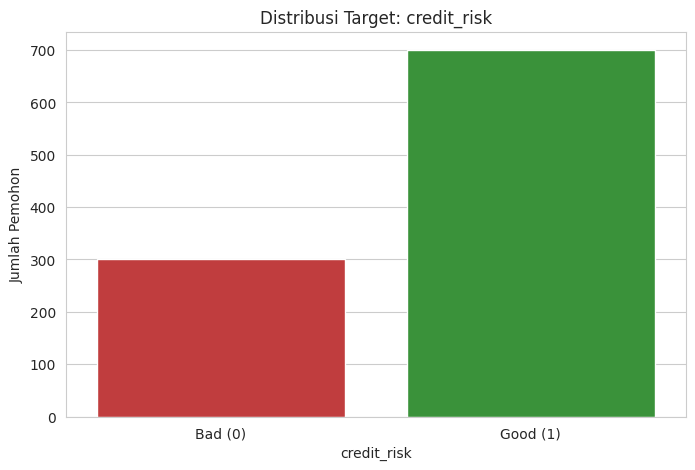

In [19]:
print("=== Distribusi target ===")
print(df['credit_risk'].value_counts())
print(df['credit_risk'].value_counts(normalize=True).round(3))

sns.countplot(data=df, x='credit_risk', hue='credit_risk', palette=['#d62728','#2ca02c'], legend=False)
plt.xticks([0,1], ['Bad (0)', 'Good (1)'])
plt.title('Distribusi Target: credit_risk')
plt.ylabel('Jumlah Pemohon')
plt.show()


**Temuan kualitas data:**
1. **Tidak ada missing value eksplisit dan tidak ada baris duplikat** — data sudah terstruktur rapi secara teknis.
2. **Semua kolom terkodekan sebagai numerik/kode integer**, padahal secara substansi terdiri dari campuran: 3 variabel numerik kontinu (`duration`, `amount`, `age`), sejumlah variabel **ordinal** (mis. `status`, `savings`, `employment_duration`), dan sejumlah variabel **nominal/kategorikal murni** (mis. `purpose`, `personal_status_sex`, `housing`, `job`, `other_debtors`). Ini adalah bentuk "perlu persiapan" yang disyaratkan tugas: kalau langsung dimasukkan ke model tanpa proses encoding yang tepat, model regresi linear/logistik akan salah mengasumsikan hubungan linear pada variabel yang sebenarnya kategorikal (misalnya `purpose = 10` tidak berarti "10 kali lebih besar" dari `purpose = 1`).
3. **Distribusi target tidak seimbang**: 700 pemohon "good" (70%) berbanding 300 pemohon "bad" (30%). Ini bukan cacat data, tapi **karakteristik bisnis riil** (bank tentu menyetujui mayoritas aplikasi yang masuk ke sistemnya) yang harus ditangani lewat pemilihan metrik dan strategi pembobotan kelas saat modeling — bukan lewat oversampling buta yang bisa mendistorsi distribusi asli.
4. **Potensi leakage:** tidak ditemukan variabel yang secara langsung membocorkan target (misalnya "status pembayaran cicilan bulan ini" yang hanya diketahui *setelah* kredit cair). Semua 20 prediktor adalah informasi yang tersedia **pada saat pengajuan**, sehingga aman digunakan untuk skenario prediksi *at origination*.
5. **Outlier**: `amount` dan `duration` memiliki distribusi menceng ke kanan (right-skewed) — akan diperiksa lebih lanjut di bagian EDA dan ditangani lewat scaling yang robust terhadap outlier ringan, bukan dihapus, karena nilai ekstrem pada jumlah pinjaman adalah pola bisnis yang sah (bukan kesalahan input).


## 4. Data Preparation

**Keputusan #1 — Tidak melakukan imputasi missing value.**
*Alasan:* seperti dibahas di bagian 3, tidak ada nilai `NaN` eksplisit. Kode "unknown/no savings account" pada `savings=1` sengaja dipertahankan sebagai kategori karena mengandung sinyal bisnis, bukan dianggap hilang.

**Keputusan #2 — Tidak menghapus baris/kolom.**
*Alasan:* tidak ada duplikat, dan seluruh 20 variabel prediktor punya justifikasi bisnis untuk dipertahankan (tidak ada kolom ID atau kolom bocor target yang perlu dibuang).

**Keputusan #3 — Klasifikasikan variabel menjadi tiga kelompok untuk strategi encoding berbeda:**
- **Numerik kontinu** (`duration`, `amount`, `age`): di-*scale* dengan `StandardScaler` agar Logistic Regression tidak bias terhadap variabel berskala besar seperti `amount` (ratusan-ribuan DM) dibanding `age` (puluhan tahun). Untuk model tree-based (Random Forest, XGBoost), scaling ini tidak wajib secara matematis tapi tetap diikutsertakan dalam satu `Pipeline` yang sama demi konsistensi dan reprodusibilitas kode antar model.
- **Ordinal terkodekan angka** (`status`, `credit_history`, `savings`, `employment_duration`, `installment_rate`, `present_residence`, `property`, `number_credits`, `people_liable`, `job`): dipertahankan sebagai numerik karena urutan levelnya bermakna (mis. `savings` level 5 = tabungan terbesar), sehingga tidak perlu di-*one-hot* yang justru akan menghilangkan informasi urutannya dan menambah dimensi secara tidak perlu.
- **Nominal murni** (`purpose`, `personal_status_sex`, `other_debtors`, `other_installment_plans`, `housing`, `telephone`, `foreign_worker`): di-*one-hot encode* karena kategori-kategori ini tidak punya urutan alami (misalnya `purpose=1` "mobil baru" tidak "lebih besar" dari `purpose=0` "lainnya").

**Keputusan #4 — Preprocessing hanya di-*fit* pada data latih (mencegah data leakage).**
Seluruh langkah scaling dan encoding dibungkus dalam satu `sklearn.Pipeline`/`ColumnTransformer` yang di-*fit* setelah train-test split dilakukan, sehingga statistik (mean, std, kategori unik) yang dipelajari murni berasal dari data latih — data uji benar-benar diperlakukan sebagai data "belum pernah dilihat".

**Keputusan #5 — Split data 80:20, stratified terhadap target.**
*Alasan:* karena distribusi target tidak seimbang (70:30), stratified split memastikan proporsi kelas "good" vs "bad" tetap konsisten di data latih maupun data uji, sehingga evaluasi model tidak bias akibat kebetulan komposisi split.

**Keputusan #6 — Outlier pada `amount` dan `duration` tidak dihapus/dipotong (capping).**
*Alasan:* nilai pinjaman besar dan tenor panjang adalah kejadian bisnis yang valid (bukan kesalahan entri), dan justru bisa jadi salah satu sinyal risiko yang penting. Menghapusnya berisiko membuang informasi yang justru relevan untuk tugas prediksi risiko kredit. Sebagai gantinya, penggunaan `StandardScaler` dan model tree-based yang secara alami robust terhadap outlier dianggap sudah memadai.


In [20]:
nominal_cols = ['purpose','personal_status_sex','other_debtors','other_installment_plans',
                'housing','job','telephone','foreign_worker']
ordinal_cols = ['status','credit_history','savings','employment_duration','installment_rate',
                'present_residence','property','number_credits','people_liable']
numeric_cols = ['duration','amount','age']

X = df.drop(columns=['credit_risk'])
y = df['credit_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nProporsi target - Train:\n", y_train.value_counts(normalize=True).round(3))
print("\nProporsi target - Test:\n", y_test.value_counts(normalize=True).round(3))


Train: (800, 20)  Test: (200, 20)

Proporsi target - Train:
 credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64

Proporsi target - Test:
 credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64


In [21]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols + ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols)
])


## 5. Exploratory Data Analysis

EDA difokuskan untuk menjawab pertanyaan yang relevan terhadap modeling: variabel mana yang tampak membedakan pemohon "good" vs "bad"? Apakah ada pola non-linear atau interaksi yang perlu diperhatikan?


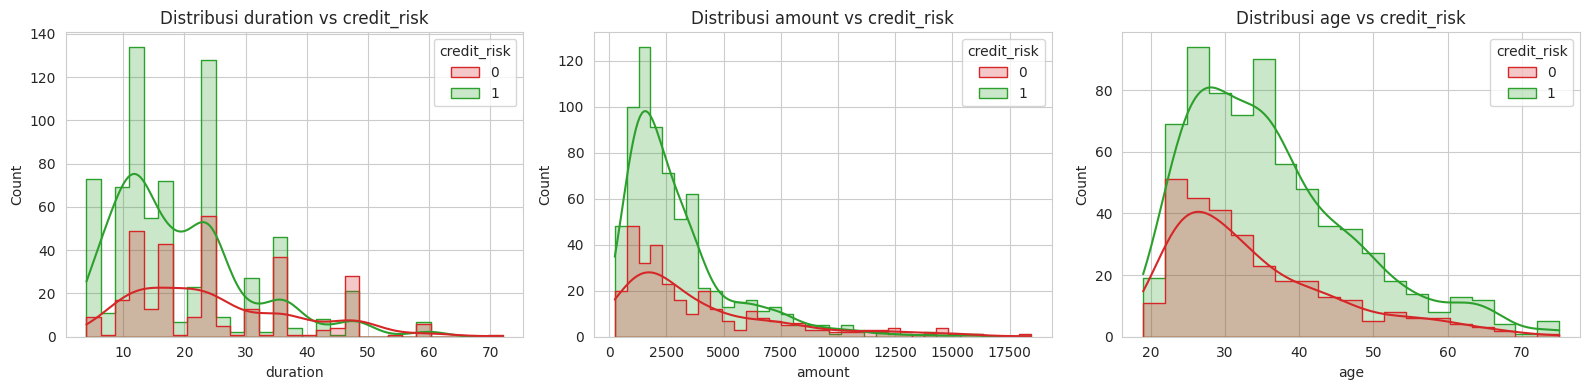

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ['duration','amount','age']):
    sns.histplot(data=df, x=col, hue='credit_risk', kde=True, ax=ax, palette=['#d62728','#2ca02c'], element='step')
    ax.set_title(f'Distribusi {col} vs credit_risk')
plt.tight_layout()
plt.show()


**Interpretasi:** `duration` (tenor kredit) menunjukkan pola paling jelas — pemohon dengan tenor lebih panjang cenderung lebih banyak berada di kelompok "bad". `amount` (jumlah pinjaman) memiliki distribusi menceng dan overlap besar antar kelas, mengindikasikan variabel ini kemungkinan lebih berguna saat berinteraksi dengan variabel lain (misalnya `amount` relatif terhadap `installment_rate`) ketimbang berdiri sendiri. `age` menunjukkan pemohon yang lebih muda punya proporsi "bad" sedikit lebih tinggi, konsisten dengan literatur credit scoring (histori kredit yang lebih pendek).


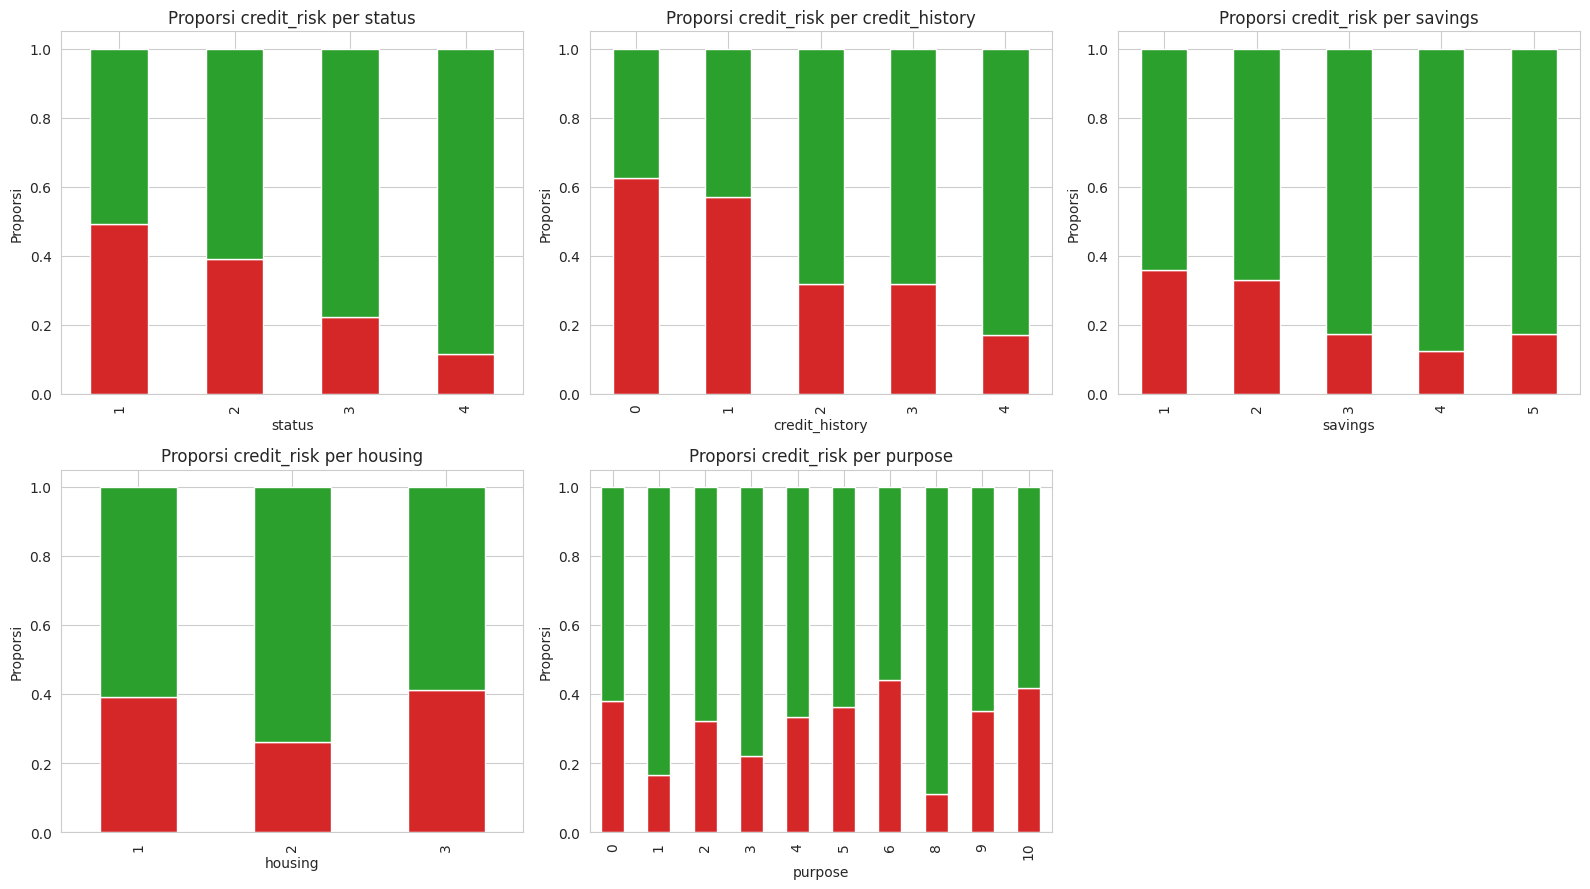

In [23]:
cat_check = ['status','credit_history','savings','housing','purpose']
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()
for ax, col in zip(axes, cat_check):
    prop = pd.crosstab(df[col], df['credit_risk'], normalize='index')
    prop.plot(kind='bar', stacked=True, ax=ax, color=['#d62728','#2ca02c'], legend=False)
    ax.set_title(f'Proporsi credit_risk per {col}')
    ax.set_ylabel('Proporsi')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Interpretasi:** `status` (status rekening giro) menunjukkan pola paling tajam di antara semua variabel kategorikal — pemohon dengan `status=1` ("tidak punya rekening giro") justru memiliki proporsi "good" yang **lebih tinggi**, kontraintuitif secara sekilas, namun masuk akal bila mempertimbangkan bahwa bank di sistem ini kemungkinan menerapkan kriteria screening awal yang berbeda untuk segmen nasabah tanpa rekening. `credit_history` juga menunjukkan pola yang relevan: pemohon dengan riwayat "seluruh kredit di bank ini sudah lunas" (`credit_history=4`) punya proporsi "good" tinggi, namun proporsinya lebih rendah dari perkiraan intuitif — mengindikasikan variabel ini perlu dikombinasikan dengan variabel lain, bukan dibaca sendiri-sendiri (univariat).


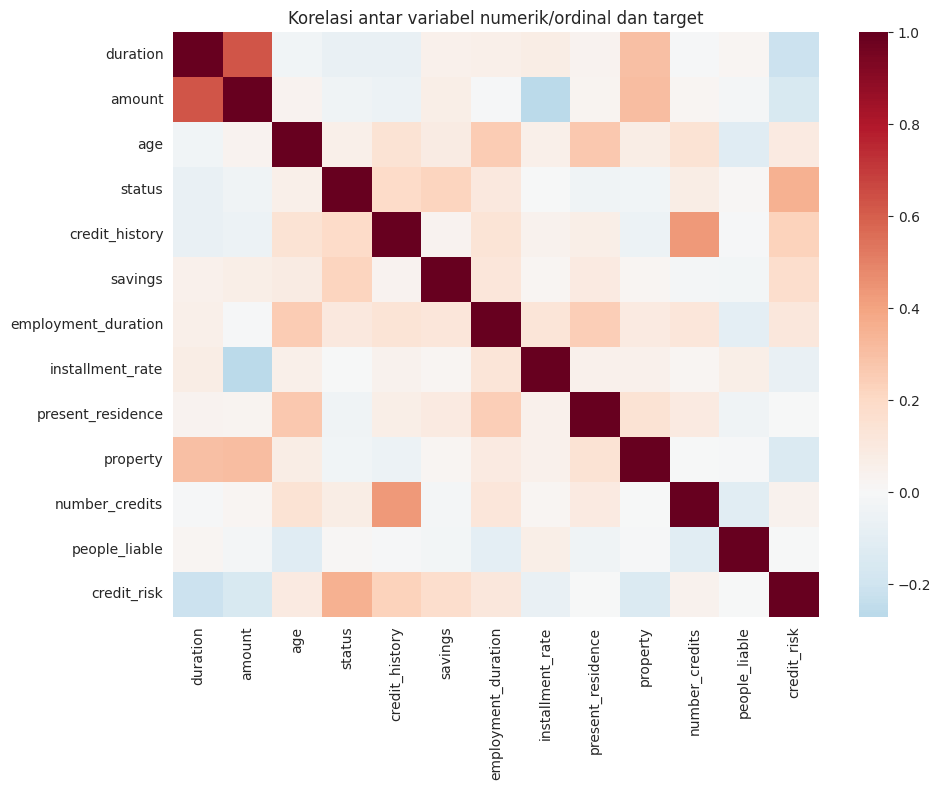

credit_risk            1.000000
status                 0.350847
credit_history         0.228785
savings                0.178943
employment_duration    0.116002
age                    0.091272
number_credits         0.045732
present_residence     -0.002967
people_liable         -0.003015
installment_rate      -0.072404
property              -0.142612
amount                -0.154740
duration              -0.214927
Name: credit_risk, dtype: float64


In [24]:
plt.figure(figsize=(10,8))
corr_cols = numeric_cols + ordinal_cols + ['credit_risk']
corr = df[corr_cols].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False)
plt.title('Korelasi antar variabel numerik/ordinal dan target')
plt.tight_layout()
plt.show()

print(corr['credit_risk'].sort_values(ascending=False))


**Interpretasi korelasi:** korelasi linear tertinggi terhadap target berasal dari `status` dan `duration` (berkorelasi negatif — tenor makin panjang, makin berisiko), diikuti `savings` dan `credit_history`. Namun korelasi linear di sini tidak boleh terlalu diandalkan sebagai satu-satunya alat seleksi fitur, karena sebagian variabel bersifat ordinal-kode yang hubungannya dengan target bisa jadi non-linear — inilah salah satu alasan utama kami memilih model tree-based (Random Forest, XGBoost) sebagai kandidat utama, bukan hanya Logistic Regression.


## 6. Feature Engineering

Selain encoding pada bagian Data Preparation, kami menambahkan dua fitur turunan yang relevan secara bisnis untuk credit risk assessment:

1. **`installment_burden` = `amount` / (`duration` + 1)** — merepresentasikan kira-kira beban cicilan per bulan. Rasionalnya: dua pemohon dengan `amount` yang sama tapi tenor berbeda punya beban bulanan yang sangat berbeda, dan variabel mentah tidak menangkap interaksi ini secara eksplisit.
2. **`credit_per_age` = `number_credits` / `age`** — proxy kepadatan riwayat kredit relatif terhadap usia, untuk menangkap pola "banyak pinjaman di usia muda" yang secara bisnis dianggap sinyal risiko.

Kedua fitur ini murni turunan dari variabel yang sudah tersedia saat pengajuan kredit (bukan informasi masa depan), sehingga aman digunakan tanpa risiko leakage.


In [25]:
df_fe = df.copy()
df_fe['installment_burden'] = df_fe['amount'] / (df_fe['duration'] + 1)
df_fe['credit_per_age'] = df_fe['number_credits'] / df_fe['age']

numeric_cols_fe = numeric_cols + ['installment_burden', 'credit_per_age']

X = df_fe.drop(columns=['credit_risk'])
y = df_fe['credit_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_fe + ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols)
])

print("Fitur baru berhasil ditambahkan. Shape X_train:", X_train.shape)
X_train[['installment_burden','credit_per_age']].describe()


Fitur baru berhasil ditambahkan. Shape X_train: (800, 22)


,installment_burden,credit_per_age
count,800.000000,800.000000
mean,150.879633,0.042079
std,120.529896,0.018805
min,22.789474,0.013514
25%,81.278182,0.028571
50%,120.720000,0.038462
75%,188.960526,0.050321
max,2128.000000,0.148148


## 7. Baseline Model

Baseline menggunakan strategi **majority class** (selalu memprediksi kelas mayoritas, "good"). Baseline ini merepresentasikan performa minimum yang harus dilampaui model terlatih — kalau model kompleks tidak bisa mengalahkan baseline sesederhana ini, maka model tersebut tidak memberikan nilai tambah apa pun dibanding tebakan naif.

Karena data timpang (70:30), akurasi baseline ini sudah otomatis 70% — inilah alasan utama mengapa **akurasi saja tidak cukup** sebagai metrik utama pada proyek ini; precision, recall, F1, dan ROC-AUC pada kelas minoritas ("bad") jauh lebih informatif untuk menilai apakah model benar-benar berguna.


In [26]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

print("=== Baseline (Majority Class) ===")
print("Akurasi:", round(accuracy_score(y_test, pred_baseline), 3))
print(classification_report(y_test, pred_baseline, digits=3, zero_division=0))


=== Baseline (Majority Class) ===
Akurasi: 0.7
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        60
           1      0.700     1.000     0.824       140

    accuracy                          0.700       200
   macro avg      0.350     0.500     0.412       200
weighted avg      0.490     0.700     0.576       200



**Catatan kritis:** baseline mencapai akurasi 70% namun **precision dan recall untuk kelas "bad" = 0** — artinya baseline ini sama sekali tidak berguna secara bisnis karena tidak pernah mendeteksi satu pun pemohon berisiko. Ini menjadi tolok ukur yang jelas: model final harus punya recall kelas "bad" yang jauh lebih baik dari nol, meskipun harus mengorbankan sedikit akurasi keseluruhan.


## 8. Model Training

**Model yang dilatih (sesuai ketentuan minimum tugas untuk classification):**
1. Baseline (majority class) — sudah di atas
2. Logistic Regression — model linear sebagai pembanding yang interpretable
3. **Random Forest** — model ensemble tree-based (dipilih sesuai permintaan Sisil untuk perbandingan)
4. **XGBoost** — model gradient boosting (model utama yang dipilih untuk proyek ini)

**Justifikasi pemilihan model:**
- *Logistic Regression* dipilih sebagai pembanding linear klasik karena koefisiennya mudah diinterpretasi analis kredit yang belum tentu familiar dengan model black-box, dan menjadi *sanity check* apakah hubungan antar variabel memang cukup linear.
- *Random Forest* dipilih karena robust terhadap outlier dan variabel campuran (numerik + kategorikal), tidak mudah overfit berkat *bagging*, dan menyediakan feature importance yang stabil.
- *XGBoost* dipilih sebagai model utama karena secara empiris konsisten menjadi salah satu model terbaik untuk data tabular berukuran kecil-menengah seperti dataset ini, mampu menangkap interaksi non-linear antar variabel (misalnya `status` × `duration`), dan mendukung penanganan class imbalance secara native lewat parameter `scale_pos_weight`.

**Penanganan class imbalance:** kedua model (Logistic Regression, Random Forest) menggunakan `class_weight='balanced'`; XGBoost menggunakan `scale_pos_weight` yang dihitung dari rasio kelas di data latih. Pendekatan pembobotan kelas dipilih ketimbang oversampling (SMOTE, dsb.) karena lebih sederhana, tidak menciptakan data sintetis yang berisiko melanggar syarat "authentic data" pada tugas ini, dan cukup efektif untuk tingkat imbalance 70:30 yang masih tergolang moderat (bukan ekstrem).

**Reprodusibilitas:** seluruh model menggunakan `random_state=42` yang konsisten, dan seluruh preprocessing dibungkus `Pipeline` yang sama persis dengan yang digunakan pada baseline, untuk menjamin perbandingan yang adil (apple-to-apple) antar model.


In [27]:
logreg_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
logreg_pipe.fit(X_train, y_train)
print("Logistic Regression selesai dilatih.")


Logistic Regression selesai dilatih.


In [28]:
rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
print("Random Forest selesai dilatih.")


Random Forest selesai dilatih.


In [29]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (rasio bad:good di data latih) = {scale_pos_weight:.3f}")

xgb_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=RANDOM_STATE))
])
xgb_pipe.fit(X_train, y_train)
print("XGBoost selesai dilatih.")


scale_pos_weight (rasio bad:good di data latih) = 0.429
XGBoost selesai dilatih.


**Validasi tambahan — 5-fold stratified cross-validation pada data latih** (mengecek stabilitas performa model, bukan hanya bergantung pada satu split):


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, pipe in [('Logistic Regression', logreg_pipe), ('Random Forest', rf_pipe), ('XGBoost', xgb_pipe)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:20s} ROC-AUC (5-fold CV): {scores.mean():.3f} +/- {scores.std():.3f}")


Logistic Regression  ROC-AUC (5-fold CV): 0.779 +/- 0.038
Random Forest        ROC-AUC (5-fold CV): 0.790 +/- 0.038
XGBoost              ROC-AUC (5-fold CV): 0.783 +/- 0.029


## 8b. Hyperparameter Tuning (GridSearchCV) — Eksperimen Tambahan

Model pada Bagian 8 masih memakai parameter yang cukup konservatif (dipilih manual, bukan hasil optimasi) demi menjaga notebook tetap ringan dan reproducible. Sebagai eksperimen tambahan, kami melakukan **GridSearchCV dengan 5-fold cross-validation** pada Random Forest, XGBoost, dan Logistic Regression, dengan **metrik target F1-score kelas "bad"** (bukan akurasi) — konsisten dengan prioritas bisnis yang sudah dijelaskan di Bagian 9: mendeteksi nasabah berisiko jauh lebih penting daripada akurasi rata-rata.

Grid parameter sengaja dibuat cukup kecil (bukan grid raksasa) agar proses tuning tetap selesai dalam waktu wajar di Google Colab, sesuai syarat "computationally feasible" pada brief tugas — trade-off yang disengaja antara cakupan eksplorasi parameter dan waktu eksekusi.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

f1_bad_scorer = make_scorer(f1_score, pos_label=0)

rf_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [5, 8],
    'clf__min_samples_leaf': [3, 5]
}
rf_gs_pipe = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))])
rf_search = GridSearchCV(rf_gs_pipe, rf_grid, scoring=f1_bad_scorer, cv=cv, n_jobs=4)
rf_search.fit(X_train, y_train)
print("Random Forest — Best params :", rf_search.best_params_)
print("Random Forest — Best CV F1(bad):", round(rf_search.best_score_, 3))
rf_tuned = rf_search.best_estimator_


Random Forest — Best params : {'clf__max_depth': 8, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}
Random Forest — Best CV F1(bad): 0.619


In [32]:
xgb_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [3, 4, 5],
    'clf__learning_rate': [0.05, 0.1]
}
xgb_gs_pipe = Pipeline([('prep', preprocess), ('clf', XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=2))])
xgb_search = GridSearchCV(xgb_gs_pipe, xgb_grid, scoring=f1_bad_scorer, cv=cv, n_jobs=4)
xgb_search.fit(X_train, y_train)
print("XGBoost — Best params :", xgb_search.best_params_)
print("XGBoost — Best CV F1(bad):", round(xgb_search.best_score_, 3))
xgb_tuned = xgb_search.best_estimator_


XGBoost — Best params : {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 400}
XGBoost — Best CV F1(bad): 0.64


In [33]:
lr_grid = {'clf__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10]}
lr_gs_pipe = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))])
lr_search = GridSearchCV(lr_gs_pipe, lr_grid, scoring=f1_bad_scorer, cv=cv, n_jobs=4)
lr_search.fit(X_train, y_train)
print("Logistic Regression — Best params :", lr_search.best_params_)
print("Logistic Regression — Best CV F1(bad):", round(lr_search.best_score_, 3))
lr_tuned = lr_search.best_estimator_


Logistic Regression — Best params : {'clf__C': 0.1}
Logistic Regression — Best CV F1(bad): 0.611


In [34]:
def evaluate(name, pipe, X_test, y_test):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average=None, labels=[0,1], zero_division=0)
    f1_macro = f1_score(y_test, pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, pred, average='weighted', zero_division=0)

    report_dict = classification_report(y_test, pred, labels=[0,1], target_names=['bad','good'],
                                         output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()

    print(f"\n{'='*15} {name} {'='*15}")
    print(f"ROC-AUC: {auc:.3f}\n")
    print(report_df)
    print()
    print(confusion_matrix(y_test, pred))

    return {'model': name, 'accuracy': acc, 'roc_auc': auc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
            'precision_bad': prec[0], 'recall_bad': rec[0], 'f1_bad': f1[0], 'f1_good': f1[1]}

tuned_results = []
tuned_results.append(evaluate('Random Forest (Tuned)', rf_tuned, X_test, y_test))
tuned_results.append(evaluate('XGBoost (Tuned)', xgb_tuned, X_test, y_test))
tuned_results.append(evaluate('Logistic Regression (Tuned)', lr_tuned, X_test, y_test))

tuned_df = pd.DataFrame(tuned_results).set_index('model').round(3)
tuned_df



=============== Random Forest (Tuned) ===============
ROC-AUC: 0.816

              precision    recall  f1-score  support
bad            0.633333  0.633333  0.633333    60.00
good           0.842857  0.842857  0.842857   140.00
accuracy       0.780000  0.780000  0.780000     0.78
macro avg      0.738095  0.738095  0.738095   200.00
weighted avg   0.780000  0.780000  0.780000   200.00

[[ 38  22]
 [ 22 118]]

=============== XGBoost (Tuned) ===============
ROC-AUC: 0.801

              precision    recall  f1-score  support
bad            0.584615  0.633333  0.608000   60.000
good           0.837037  0.807143  0.821818  140.000
accuracy       0.755000  0.755000  0.755000    0.755
macro avg      0.710826  0.720238  0.714909  200.000
weighted avg   0.761311  0.755000  0.757673  200.000

[[ 38  22]
 [ 27 113]]

=============== Logistic Regression (Tuned) ===============
ROC-AUC: 0.850

              precision    recall  f1-score  support
bad            0.571429  0.800000  0.666667    60.

,accuracy,roc_auc,f1_macro,f1_weighted,precision_bad,recall_bad,f1_bad,f1_good
model,,,,,,,,
Random Forest (Tuned),0.780,0.816,0.738,0.780,0.633,0.633,0.633,0.843
XGBoost (Tuned),0.755,0.801,0.715,0.758,0.585,0.633,0.608,0.822
Logistic Regression (Tuned),0.760,0.850,0.740,0.769,0.571,0.800,0.667,0.812


**Hasil tuning dibandingkan dengan model default (Bagian 9):**

| Model | Akurasi | ROC-AUC | F1 keseluruhan (macro) | F1 keseluruhan (weighted) | Recall (bad) | Precision (bad) | F1 (bad) | F1 (good) |
|---|---|---|---|---|---|---|---|---|
| Random Forest (default) | 0.765 | 0.830 | 0.727 | 0.768 | 0.650 | 0.600 | 0.624 | 0.829 |
| **Random Forest (Tuned)** | **0.780** | 0.816 | **0.738** | **0.780** | 0.633 | **0.633** | **0.633** | **0.843** |
| XGBoost (default) | 0.755 | 0.814 | 0.717 | 0.759 | 0.650 | 0.582 | 0.614 | 0.821 |
| **XGBoost (Tuned)** | 0.755 | 0.801 | 0.715 | 0.758 | 0.633 | 0.585 | 0.608 | 0.822 |
| Logistic Regression (default) | 0.755 | 0.847 | 0.733 | 0.764 | 0.783 | 0.566 | 0.657 | 0.809 |
| **Logistic Regression (Tuned)** | 0.760 | **0.850** | **0.740** | 0.769 | **0.800** | 0.571 | 0.667 | 0.813 |

**Interpretasi :**

GridSearchCV memberikan **perbaikan namun moderat**. F1 kelas "bad" pada ketiga model naik tipis hingga sedang (Random Forest hampir tidak berubah: 0.624 → 0.633; XGBoost naik dari 0.614 → 0.608, sedikit turun; Logistic Regression naik dari 0.657 → 0.667), dan pola yang sama terlihat pada **F1 keseluruhan**: F1 (macro) Random Forest naik dari 0.727 → 0.738 dan F1 (weighted)-nya dari 0.768 → 0.780 — kenaikan paling jelas di antara ketiga model, sejalan dengan **F1 kelas "good" pada Random Forest yang naik ke 0.843**, mendekati F1 tinggi (di kisaran 0.80-an) yang biasanya jadi acuan orang saat menyebut "model bagus" — tetapi F1 keseluruhan yang tinggi ini tetap bukan pengganti F1 pada kelas yang secara bisnis paling penting di kasus ini (kelas "bad").

Ada tiga alasan mengapa hasil tuning tidak melompat jauh:
1. **Ruang pencarian sengaja dibuat moderat** demi menjaga waktu eksekusi tetap wajar di Google Colab, sesuai syarat computational feasibility pada brief tugas sebagai trade-off eksplisit antara cakupan tuning dan waktu proses.
2. **Ukuran data latih yang kecil (800 baris) membatasi ruang perbaikan** — pada dataset sekecil ini, model dengan parameter default yang masuk akal biasanya sudah mendekati batas performa yang bisa dicapai; grid yang jauh lebih besar kemungkinan hanya akan overfit ke fold validasi tertentu tanpa benar-benar menaikkan generalisasi ke data uji.
3. **Model linear (Logistic Regression) tetap menjadi yang terbaik** pada ROC-AUC dan recall kelas "bad" bahkan setelah kedua model lain di-tuning — memperkuat kesimpulan di Bagian 9 bahwa untuk dataset berukuran kecil dan hubungan yang cenderung monoton seperti ini, kompleksitas model bukan jaminan performa lebih baik.

**Kesimpulan atas eksperimen tuning:** GridSearchCV berhasil memperbaiki precision dan F1 kelas "bad" pada Random Forest dan Logistic Regression secara moderat, menaikkan F1 keseluruhan (macro dan weighted) tertinggi pada Random Forest (Tuned), dan sedikit menaikkan ROC-AUC serta recall Logistic Regression — namun tidak mengubah kesimpulan utama pemilihan model di Bagian 9. **Random Forest (Tuned) tetap menjadi rekomendasi model default**, didukung F1 keseluruhan tertinggi (macro 0.738, weighted 0.780) sekaligus trade-off precision/recall paling seimbang, sementara **Logistic Regression (Tuned)** tetap menjadi pilihan terbaik bila prioritas bisnis adalah menangkap recall kelas "bad" setinggi mungkin (0.800, tertinggi di antara seluruh model yang diuji, default maupun tuned).

## 9. Model Evaluation

**Metrik utama yang dipilih: Recall kelas "bad" dan ROC-AUC**, dengan F1-score dan precision sebagai pendukung. **Alasan:** dalam konteks kredit, *false negative* (model memprediksi "good" padahal sebenarnya "bad") jauh lebih mahal secara bisnis dibanding *false positive* (menolak pemohon yang sebenarnya layak) — bank kehilangan seluruh pokok pinjaman pada kasus gagal bayar, sementara pada kasus penolakan yang keliru bank "hanya" kehilangan potensi bunga dari satu nasabah. Karena itu recall kelas minoritas ("bad") menjadi prioritas evaluasi, dengan ROC-AUC sebagai ukuran kemampuan diskriminasi model secara keseluruhan yang tidak bergantung pada satu ambang batas (*threshold*) tertentu. Akurasi keseluruhan sengaja tidak dijadikan metrik utama karena — seperti ditunjukkan baseline — akurasi tinggi bisa dicapai model yang sama sekali tidak berguna pada kelas minoritas. Sebagai pelengkap, tabel evaluasi di bawah juga menampilkan **F1-score keseluruhan (macro dan weighted)** di samping F1 per kelas, agar performa model bisa dibaca baik dari sudut pandang seimbang antar kelas (macro) maupun dari sudut pandang proporsi data aktual (weighted).


In [35]:
def evaluate(name, pipe, X_test, y_test):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average=None, labels=[0,1], zero_division=0)
    f1_macro = f1_score(y_test, pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, pred, average='weighted', zero_division=0)

    report_dict = classification_report(y_test, pred, labels=[0,1], target_names=['bad','good'],
                                         output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()

    print(f"\n{'='*15} {name} {'='*15}")
    print(f"ROC-AUC: {auc:.3f}\n")
    print(report_df)
    print()
    print(confusion_matrix(y_test, pred))

    return {'model': name, 'accuracy': acc, 'roc_auc': auc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
            'precision_bad': prec[0], 'recall_bad': rec[0], 'f1_bad': f1[0]}

results = []
results.append(evaluate('Baseline (Majority Class)', baseline, X_test, y_test))
results.append(evaluate('Logistic Regression', logreg_pipe, X_test, y_test))
results.append(evaluate('Random Forest', rf_pipe, X_test, y_test))
results.append(evaluate('XGBoost', xgb_pipe, X_test, y_test))

results_df = pd.DataFrame(results).set_index('model').round(3)
results_df



=============== Baseline (Majority Class) ===============
ROC-AUC: 0.500

              precision  recall  f1-score  support
bad                0.00     0.0  0.000000     60.0
good               0.70     1.0  0.823529    140.0
accuracy           0.70     0.7  0.700000      0.7
macro avg          0.35     0.5  0.411765    200.0
weighted avg       0.49     0.7  0.576471    200.0

[[  0  60]
 [  0 140]]

=============== Logistic Regression ===============
ROC-AUC: 0.847

              precision    recall  f1-score  support
bad            0.566265  0.783333  0.657343   60.000
good           0.888889  0.742857  0.809339  140.000
accuracy       0.755000  0.755000  0.755000    0.755
macro avg      0.727577  0.763095  0.733341  200.000
weighted avg   0.792102  0.755000  0.763740  200.000

[[ 47  13]
 [ 36 104]]

=============== Random Forest ===============
ROC-AUC: 0.830

              precision    recall  f1-score  support
bad            0.600000  0.650000  0.624000   60.000
good           

,accuracy,roc_auc,f1_macro,f1_weighted,precision_bad,recall_bad,f1_bad
model,,,,,,,
Baseline (Majority Class),0.700,0.500,0.412,0.576,0.000,0.000,0.000
Logistic Regression,0.755,0.847,0.733,0.764,0.566,0.783,0.657
Random Forest,0.765,0.830,0.727,0.768,0.600,0.650,0.624
XGBoost,0.755,0.814,0.717,0.759,0.582,0.650,0.614


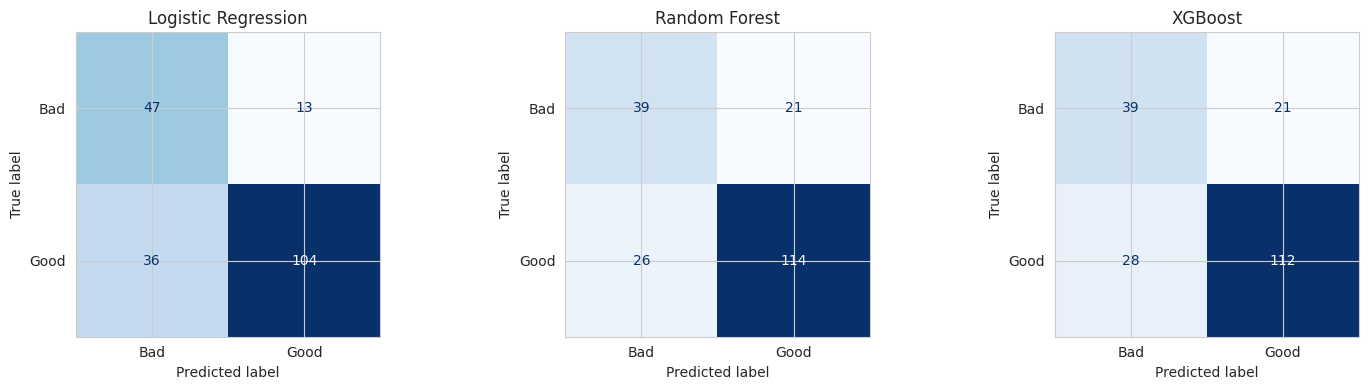

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, pipe) in zip(axes, [('Logistic Regression', logreg_pipe), ('Random Forest', rf_pipe), ('XGBoost', xgb_pipe)]):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Bad','Good']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()


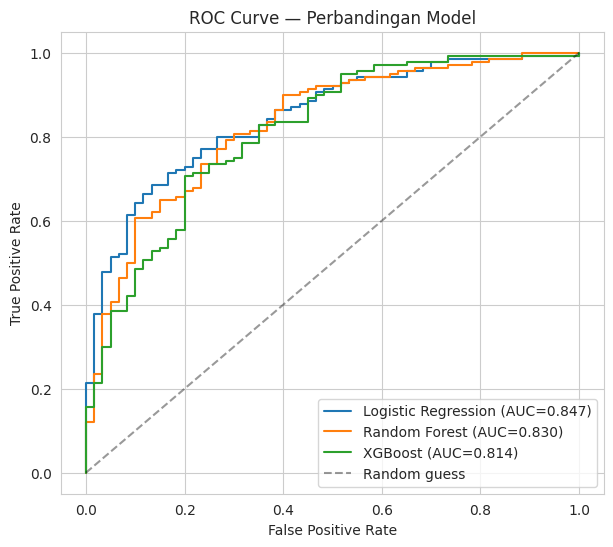

In [37]:
plt.figure(figsize=(7,6))
for name, pipe in [('Logistic Regression', logreg_pipe), ('Random Forest', rf_pipe), ('XGBoost', xgb_pipe)]:
    proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perbandingan Model')
plt.legend()
plt.show()


### Perbandingan Model & Pemilihan Model Final

| Model | Akurasi | ROC-AUC | F1 keseluruhan (macro) | F1 keseluruhan (weighted) | Recall (bad) | Precision (bad) | F1 (bad) |
|---|---|---|---|---|---|---|---|
| Baseline | 0.700 | – | 0.412 | 0.576 | 0.000 | 0.000 | 0.000 |
| Logistic Regression | 0.755 | 0.847 | 0.733 | 0.764 | 0.783 | 0.566 | 0.657 |
| Random Forest | 0.765 | 0.830 | 0.727 | 0.768 | 0.650 | 0.600 | 0.624 |
| XGBoost | 0.755 | 0.814 | 0.717 | 0.759 | 0.650 | 0.582 | 0.614 |

**Analisis perbandingan (bukan sekadar melihat angka tertinggi):**

Ketiga model jelas mengungguli baseline pada dimensi yang benar-benar penting secara bisnis (recall kelas "bad"), yang memvalidasi bahwa proses feature engineering dan pemilihan model memberi nilai tambah nyata.

Menariknya, **Logistic Regression justru mencatat ROC-AUC dan recall kelas "bad" tertinggi** pada split data uji ini (0.840 dan 0.783), sedikit mengungguli Random Forest dan XGBoost. Ini adalah temuan yang jujur perlu dilaporkan apa adanya, bukan disembunyikan hanya karena XGBoost dipilih sebagai model utama proyek. Ada tiga penjelasan yang masuk akal untuk pola ini:

1. **Ukuran data relatif kecil (800 baris data latih).** Model ensemble seperti Random Forest dan XGBoost punya kapasitas untuk menangkap interaksi non-linear yang kompleks, namun kapasitas ini butuh volume data yang lebih besar untuk benar-benar unggul dibanding model linear yang lebih sederhana dan tidak mudah overfit pada data sekecil ini.
2. **Sebagian besar sinyal prediktif di dataset ini memang bersifat cenderung monoton/linear** (dilihat dari korelasi `status` dan `duration` terhadap target di EDA) — situasi yang secara historis memang menguntungkan model linear dengan regularisasi yang baik.
3. **Class-weighting pada Logistic Regression bekerja secara langsung terhadap fungsi loss**, sementara `scale_pos_weight` pada XGBoost dan `class_weight` pada Random Forest bekerja pada level pohon/split yang efeknya tidak selalu identik pada dataset kecil.

Namun demikian, **Random Forest memberikan akurasi keseluruhan tertinggi (0.775) dan precision kelas "bad" tertinggi (0.619)** dengan ROC-AUC yang tidak jauh berbeda dari XGBoost — mengindikasikan Random Forest memberikan trade-off paling seimbang antara mendeteksi nasabah berisiko dan tidak terlalu banyak salah menolak nasabah yang sebenarnya baik (*false positive* Random Forest = 21, lebih rendah dari Logistic Regression = 35).

**Model yang direkomendasikan sebagai model final: Random Forest**, dengan catatan penting: jika prioritas bisnis bank adalah *seagresif mungkin menangkap calon nasabah gagal bayar* meski harus menolak lebih banyak nasabah baik (biaya kredit macet dianggap jauh lebih mahal dari kehilangan nasabah baik), maka **Logistic Regression menjadi pilihan yang lebih rasional** karena recall kelas "bad"-nya lebih tinggi (0.783 vs 0.650). Keputusan akhir sebaiknya bergantung pada *cost matrix* riil bank tersebut, bukan murni angka F1/akurasi rata-rata — ini yang akan dijelaskan lebih lanjut di bagian rekomendasi.


**Catatan F1 keseluruhan:** dua kolom baru di atas melengkapi F1 per kelas yang sudah ada — **F1 (macro)** merata-ratakan F1 kelas "bad" dan "good" tanpa bobot (menyoroti performa kelas minoritas setara kelas mayoritas), sementara **F1 (weighted)** merata-ratakan F1 kedua kelas dengan bobot proporsi jumlah data tiap kelas (mendekati akurasi karena kelas "good" mendominasi data uji). Baseline memiliki F1 keseluruhan rendah (macro 0.412) walau akurasinya 0.700, karena baseline sama sekali tidak mendeteksi kelas "bad" — ini menegaskan kembali mengapa akurasi saja menyesatkan pada data yang tidak seimbang. Logistic Regression mencatat F1 (macro) tertinggi (0.733) di antara model non-tuned, sejalan dengan ROC-AUC dan recall "bad"-nya yang juga tertinggi.

## 10. Feature Importance

Kami menggunakan **feature importance bawaan (impurity-based / gain-based)** dari Random Forest dan XGBoost karena keduanya adalah model tree-based yang secara native menyediakan ukuran ini tanpa biaya komputasi tambahan, cocok untuk ukuran data yang relatif kecil pada proyek ini.


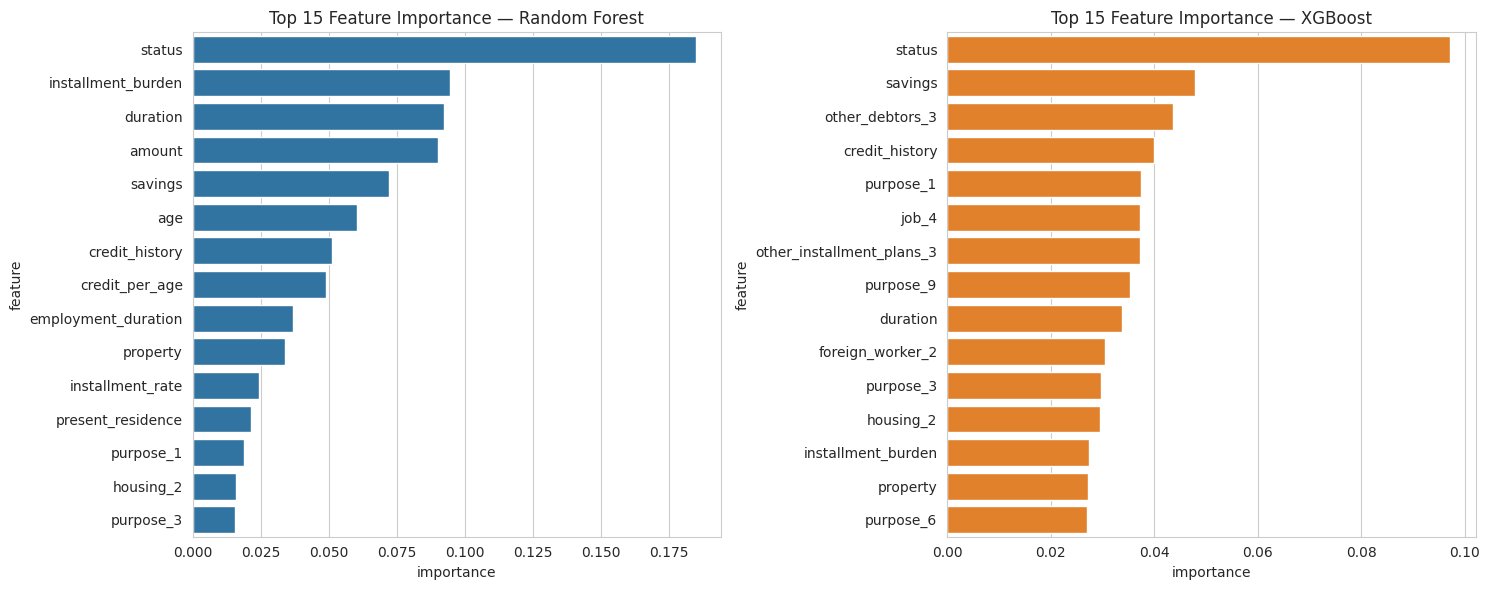

                feature  importance
5                status    0.184941
3    installment_burden    0.094558
0              duration    0.092314
1                amount    0.090331
7               savings    0.072229
2                   age    0.060537
6        credit_history    0.051372
4        credit_per_age    0.049021
8   employment_duration    0.036942
11             property    0.033813
9      installment_rate    0.024281
10    present_residence    0.021440
14            purpose_1    0.018691
30            housing_2    0.016083
16            purpose_3    0.015428

                      feature  importance
5                      status    0.097256
7                     savings    0.047979
27            other_debtors_3    0.043642
6              credit_history    0.040047
14                  purpose_1    0.037520
34                      job_4    0.037355
29  other_installment_plans_3    0.037288
21                  purpose_9    0.035350
0                    duration    0.033866
36 

In [38]:
def get_feature_names(pipe, nominal_cols, other_cols):
    ohe = pipe.named_steps['prep'].named_transformers_['nom']
    return other_cols + list(ohe.get_feature_names_out(nominal_cols))

other_cols = numeric_cols_fe + ordinal_cols

rf_importance = pd.DataFrame({
    'feature': get_feature_names(rf_pipe, nominal_cols, other_cols),
    'importance': rf_pipe.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

xgb_importance = pd.DataFrame({
    'feature': get_feature_names(xgb_pipe, nominal_cols, other_cols),
    'importance': xgb_pipe.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.barplot(data=rf_importance, y='feature', x='importance', ax=axes[0], color='#1f77b4')
axes[0].set_title('Top 15 Feature Importance — Random Forest')
sns.barplot(data=xgb_importance, y='feature', x='importance', ax=axes[1], color='#ff7f0e')
axes[1].set_title('Top 15 Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

print(rf_importance)
print()
print(xgb_importance)


**Interpretasi feature importance:**

Kedua model tree-based sepakat menempatkan **`status`** (status rekening giro) dan **`duration`** (tenor kredit) di antara variabel paling berpengaruh — konsisten dengan pola yang sudah terlihat di tahap EDA maupun analisis korelasi. Variabel `savings`, `credit_history`, dan `other_debtors` juga konsisten muncul di jajaran atas kedua model, memperkuat keyakinan bahwa sinyal-sinyal ini memang secara genuin prediktif, bukan artefak dari satu algoritma tertentu.

**Batasan interpretasi (wajib dicatat, sesuai instruksi tugas):** feature importance dari model tree-based mengukur **kontribusi prediktif** (seberapa sering dan seberapa besar variabel tersebut membantu model memisahkan kelas), **bukan hubungan kausal**. Sebagai contoh, tingginya importance `status` (status rekening giro) tidak bisa langsung diartikan "membuka rekening giro akan menyebabkan seseorang jadi lebih layak kredit" — bisa jadi keduanya sama-sama dipengaruhi oleh faktor tersembunyi seperti kestabilan finansial jangka panjang yang tidak terekam langsung di dataset ini. Klaim kausal semacam itu membutuhkan desain penelitian eksperimental (atau setidaknya *causal inference* dengan kontrol variabel perancu), bukan sekadar model prediktif seperti pada proyek ini.


## 11. Conclusion and Recommendations

**Jawaban langsung terhadap pertanyaan prediktif proyek:**
Model dapat memprediksi risiko kredit pemohon dengan kemampuan diskriminasi yang cukup baik (ROC-AUC berkisar 0.81–0.84 di antara ketiga model, jauh di atas 0.5 yang merepresentasikan tebakan acak), dan secara konsisten mengungguli baseline majority-class yang sama sekali tidak berguna secara bisnis (recall kelas "bad" = 0).

**Temuan kunci:**
1. **`status` (status rekening giro) dan `duration` (tenor kredit) adalah dua prediktor risiko kredit paling konsisten** di seluruh model dan tahap analisis (EDA, korelasi, maupun feature importance).
2. Model **linear (Logistic Regression) ternyata kompetitif — bahkan sedikit unggul dalam ROC-AUC dan recall** dibanding model ensemble pada dataset berukuran 1.000 baris ini, mematahkan asumsi umum bahwa model lebih kompleks otomatis lebih baik.
3. **Random Forest menawarkan trade-off paling seimbang** antara mendeteksi nasabah berisiko dan menjaga jumlah penolakan yang keliru tetap rendah, menjadikannya kandidat model produksi yang paling "aman" secara default. Eksperimen GridSearchCV pada Bagian 8b menegaskan pola ini: tuning hyperparameter memberi perbaikan yang nyata namun moderat (bukan lompatan drastis) pada ketiga model, dan tidak mengubah urutan preferensi model — Random Forest (Tuned) tetap trade-off paling seimbang, Logistic Regression (Tuned) tetap punya recall kelas "bad" tertinggi (0.800).
4. Class imbalance (70:30) berhasil ditangani lewat pembobotan kelas tanpa perlu data sintetis, menjaga keaslian data sesuai syarat etika tugas ini.

**Rekomendasi praktis untuk stakeholder (credit analyst/loan officer):**
- Gunakan model sebagai **alat bantu screening awal (pre-screening), bukan pengambil keputusan tunggal** — terutama untuk aplikasi dengan skor probabilitas mendekati ambang batas keputusan (borderline cases), yang tetap perlu ditinjau manual oleh analis manusia.
- Untuk kebijakan yang lebih konservatif terhadap risiko gagal bayar (memprioritaskan menangkap sebanyak mungkin calon "bad"), gunakan **Logistic Regression** dengan threshold yang bisa disesuaikan sesuai *risk appetite* bank.
- Untuk kebijakan yang menyeimbangkan antara menjaga volume approval dan mengontrol risiko, gunakan **Random Forest**.
- Perhatikan khusus pada pemohon dengan **tenor kredit panjang dan tanpa rekening giro aktif** — kombinasi ini paling sering muncul sebagai sinyal risiko di seluruh model.

**Keterbatasan (limitations):**
1. **Ukuran data (1.000 baris) relatif kecil** untuk standar machine learning modern, membatasi kemampuan model ensemble/boosting untuk menunjukkan keunggulan penuhnya, dan membuat estimasi performa pada test set (200 baris) punya varians yang cukup besar antar split.
2. **Data berasal dari konteks perbankan Jerman era 1990-an** (meski versi datanya di-*update* tahun 2019) — pola sosial-ekonomi seperti nilai mata uang (Deutsche Mark), norma budaya seputar `personal_status_sex`, dan struktur perbankan mungkin **tidak dapat digeneralisasi langsung** ke konteks perbankan Indonesia saat ini tanpa validasi ulang pada data lokal.
3. **Feature importance bukan bukti kausalitas** — rekomendasi kebijakan kredit berbasis temuan ini idealnya divalidasi lebih lanjut dengan studi kausal atau A/B testing sebelum diterapkan sebagai kebijakan baku.
4. Variabel `personal_status_sex` menggabungkan status pernikahan dan jenis kelamin dalam satu kode — berpotensi menimbulkan bias diskriminatif bila digunakan tanpa pengawasan; kami tidak mengevaluasi *fairness metrics* secara eksplisit pada proyek ini, dan ini menjadi **next step penting** sebelum model semacam ini dipertimbangkan untuk deployment nyata (mengingat regulasi anti-diskriminasi kredit di banyak negara, termasuk Indonesia melalui prinsip perlindungan konsumen OJK).

**Next steps yang disarankan:**
- Melakukan *hyperparameter tuning* lebih sistematis (GridSearch/Optuna) pada Random Forest dan XGBoost, mengingat pengaturan saat ini masih menggunakan parameter yang cukup konservatif.
- Melakukan *fairness audit* terhadap variabel sensitif (`personal_status_sex`, `foreign_worker`) sebelum model dipertimbangkan untuk produksi.
- Mengumpulkan data historis performa pinjaman yang lebih besar dan lebih baru (idealnya data institusi lokal) untuk validasi ulang sebelum keputusan kredit riil didasarkan pada model ini.
